In [1]:
import torch
import os

# 1. Detect environment versions to fetch pre-compiled binaries
PYT = torch.__version__.split('+')[0]
CUDA = torch.version.cuda.replace('.', '')

print(f"Environment detected: PyTorch {PYT} with CUDA {CUDA}")

# 2. Install main libraries
!pip install torch-geometric pysr pyyaml colorlog tqdm -q

# 3. Fetch matching pre-compiled wheels for PyG dependencies
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv \
    -f https://data.pyg.org/whl/torch-{PYT}+cu{CUDA}.html -q

print("Installation Complete!")

Environment detected: PyTorch 2.10.0 with CUDA 128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 17.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 83.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 105.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 81.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.2 MB/s eta 0:00:00
Installation Complete!


In [2]:
import os
os.environ['GIT_TERMINAL_PROMPT'] = '0'
!rm -rf /kaggle/working/cosmic-net
!git clone https://github.com/Rusheel86/cosmic-net.git /kaggle/working/cosmic-net
os.chdir('/kaggle/working/cosmic-net')
!git log --oneline -3
!ls

Cloning into '/kaggle/working/cosmic-net'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 83 (delta 18), reused 76 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 101.13 KiB | 1.98 MiB/s, done.
Resolving deltas: 100% (18/18), done.
443984e (HEAD -> main, origin/main, origin/HEAD) change lambda scheduler
d613fc2 config: set default data source to tng
0776fe9 fix(training): replace broken lambda scheduler with strict cosine warmup
config	 fetch_log.txt	    main.py    requirements.txt  training
data	 fetch_tng_data.py  model      symbolic		 validate_data.py
deploy	 graph		    notebooks  test_results.txt
explain  LICENSE	    README.md  tests


In [3]:
import os
import pandas as pd

# Define paths
# Using the exact Kaggle input path provided
KAG_INPUT_PATH = '/kaggle/input/datasets/rusheelsharma/tng-fixed2/tng100_clustered.csv'
WORKING_DIR = '/kaggle/working/cosmic-net'
LOCAL_RAW_DATA = 'data/raw/tng100_clustered.csv'

# 1. Setup workspace
os.makedirs(os.path.join(WORKING_DIR, 'data/raw'), exist_ok=True)
os.chdir(WORKING_DIR)

# 2. Copy the data using the correct source path
if os.path.exists(KAG_INPUT_PATH):
    !cp {KAG_INPUT_PATH} {LOCAL_RAW_DATA}
    print("File copied successfully to workspace.")
else:
    # Check for common Kaggle path variations if the above fails
    alternative_path = '/kaggle/input/tng-fixed2/tng100_clustered.csv'
    if os.path.exists(alternative_path):
        !cp {alternative_path} {LOCAL_RAW_DATA}
        print("File copied using alternative path.")
    else:
        print("ERROR: File not found. Please check the 'Data' sidebar in Kaggle to verify the path.")

# 3. Verify and Validate the data
if os.path.exists(LOCAL_RAW_DATA):
    df = pd.read_csv(LOCAL_RAW_DATA)
    c = df[df['is_central'] == 1]
    diff = c['halo_mass_log'] - c['stellar_mass']

    print(f"\nRows  : {len(df)}")
    print(f"Halos : {df['group_id'].nunique()}")
    print(f"Mass Difference Mean (halo_mass - stellar_mass): {diff.mean():.3f} dex")

    if diff.mean() > 1.0:
        print("DATA CONFIRMED CORRECT — Proceeding with training.")
    else:
        raise RuntimeError("Data validation failed: stellar_mass and halo_mass are too similar.")

File copied successfully to workspace.

Rows  : 5378
Halos : 541
Mass Difference Mean (halo_mass - stellar_mass): 1.702 dex
DATA CONFIRMED CORRECT — Proceeding with training.


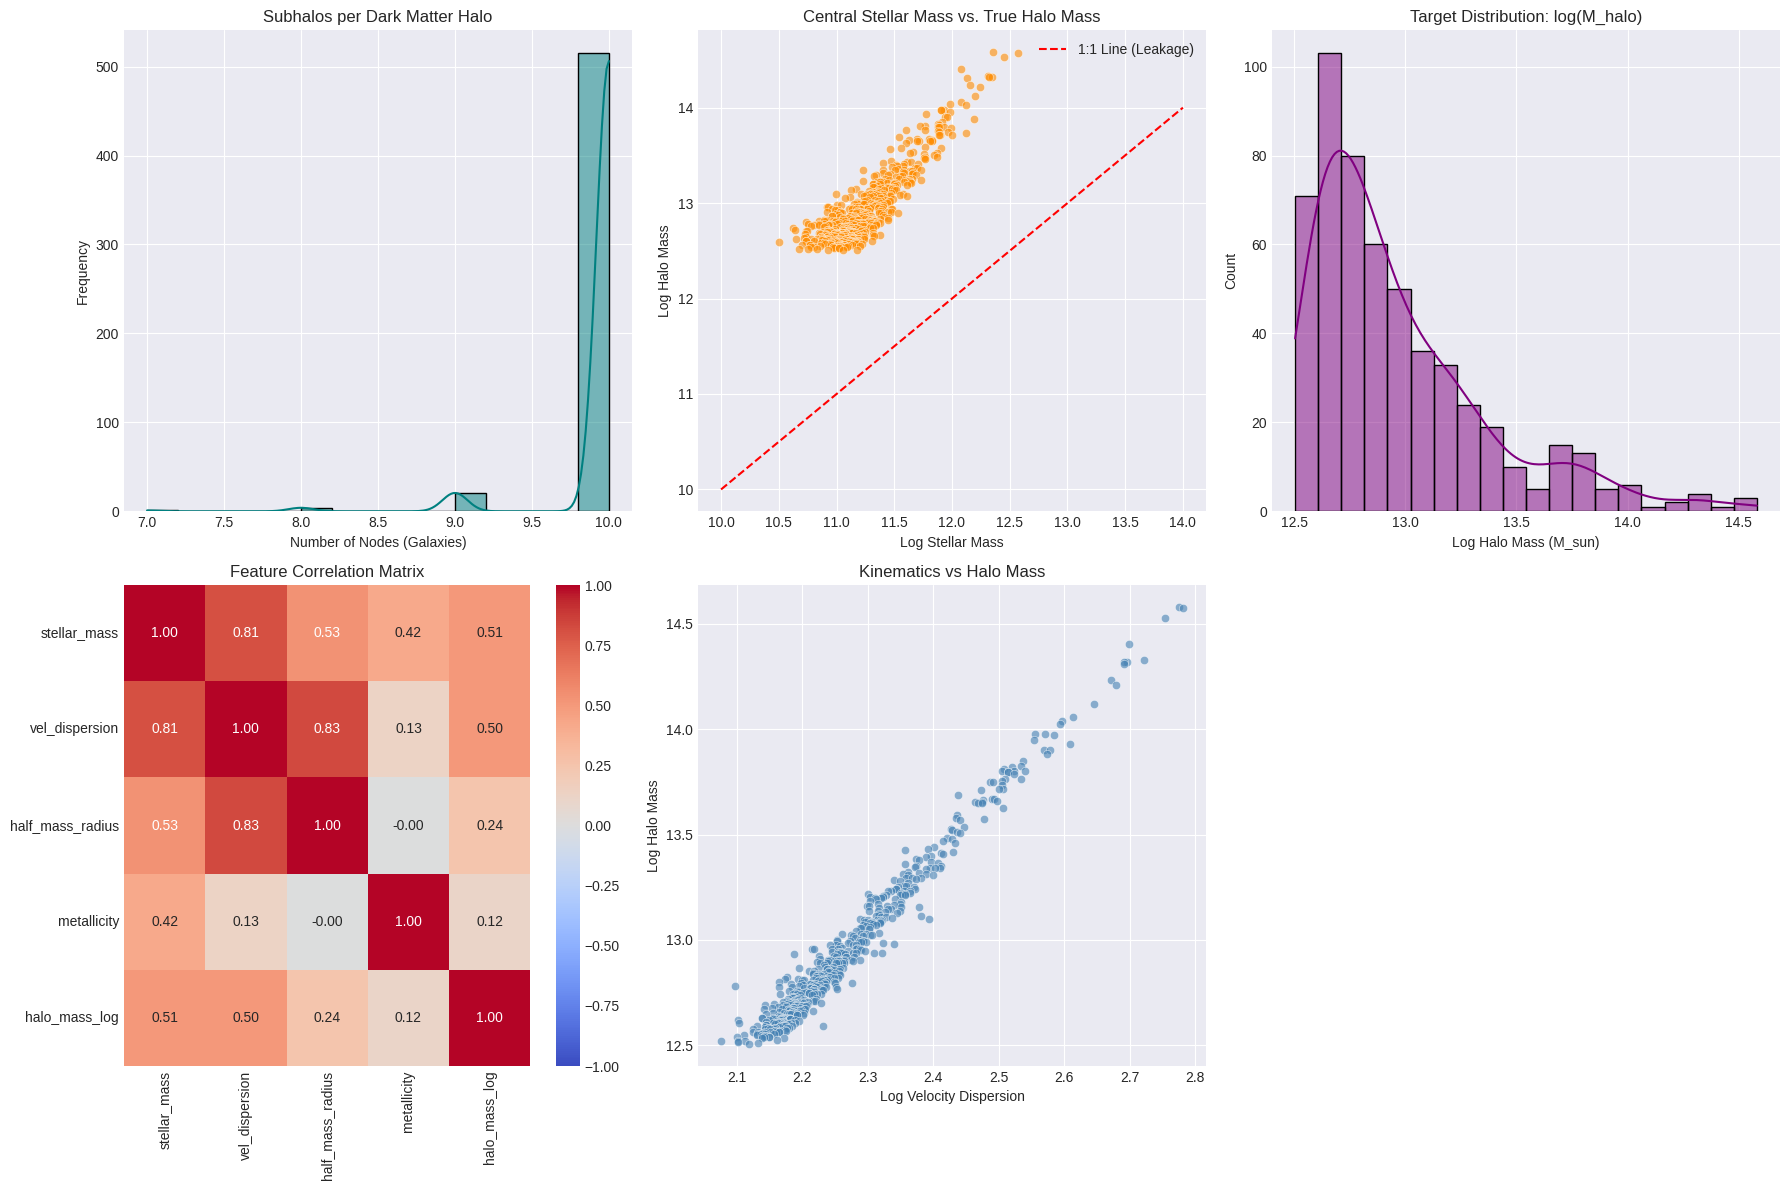

Dataset Density:
Total Graphs (Halos): 541
Total Nodes (Galaxies): 5378
Average Nodes per Graph: 9.9


In [4]:
# --- NEW CELL: Complete Data EDA ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load data
df = pd.read_csv('data/raw/tng100_clustered.csv')
os.makedirs('/kaggle/working/outputs/eda', exist_ok=True)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(18, 12))

# 1. Graph Size Distribution (Nodes per Halo)
ax1 = plt.subplot(2, 3, 1)
nodes_per_group = df.groupby('group_id').size()
sns.histplot(nodes_per_group, bins=15, kde=True, color='teal', ax=ax1)
ax1.set_title('Subhalos per Dark Matter Halo')
ax1.set_xlabel('Number of Nodes (Galaxies)')
ax1.set_ylabel('Frequency')

# 2. Target vs Central Feature (Mass Separation)
ax2 = plt.subplot(2, 3, 2)
centrals = df[df['is_central'] == 1]
sns.scatterplot(data=centrals, x='stellar_mass', y='halo_mass_log', 
                alpha=0.6, color='darkorange', ax=ax2)
ax2.plot([10, 14], [10, 14], 'r--', label='1:1 Line (Leakage)') # Reference line
ax2.set_title('Central Stellar Mass vs. True Halo Mass')
ax2.set_xlabel('Log Stellar Mass')
ax2.set_ylabel('Log Halo Mass')
ax2.legend()

# 3. Target Distribution (Regression Target)
ax3 = plt.subplot(2, 3, 3)
sns.histplot(centrals['halo_mass_log'], bins=20, kde=True, color='purple', ax=ax3)
ax3.set_title('Target Distribution: log(M_halo)')
ax3.set_xlabel('Log Halo Mass (M_sun)')

# 4. Feature Correlation Matrix
ax4 = plt.subplot(2, 3, 4)
features = ['stellar_mass', 'vel_dispersion', 'half_mass_radius', 'metallicity', 'halo_mass_log']
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', ax=ax4)
ax4.set_title('Feature Correlation Matrix')

# 5. Velocity Dispersion vs Mass (Virial Hint)
ax5 = plt.subplot(2, 3, 5)
sns.scatterplot(data=centrals, x='log_vel_dispersion', y='halo_mass_log', 
                alpha=0.6, color='steelblue', ax=ax5)
ax5.set_title('Kinematics vs Halo Mass')
ax5.set_xlabel('Log Velocity Dispersion')
ax5.set_ylabel('Log Halo Mass')

plt.tight_layout()
plt.savefig('/kaggle/working/outputs/eda/comprehensive_eda.png', dpi=150)
plt.show()

print(f"Dataset Density:")
print(f"Total Graphs (Halos): {len(nodes_per_group)}")
print(f"Total Nodes (Galaxies): {len(df)}")
print(f"Average Nodes per Graph: {nodes_per_group.mean():.1f}")

In [5]:
import os, yaml
os.chdir('/kaggle/working/cosmic-net')

config = {
    'seed': 42,
    'data': {
        'source': 'tng',
        'grouping': 'fof',
        'train_ratio': 0.70,
        'val_ratio': 0.15,
        'test_ratio': 0.15,
        'batch_size': 16,
        'num_workers': 2,
        'tng': {
            'clustered_file': 'data/raw/tng100_clustered.csv',
            'min_subhalos_per_halo': 3,
            'snapshot': 99,
            'n_halos': 600,
            'cache_dir': 'data/raw/tng_cache',
        }
    },
    'graph': {
        'method': 'radius',
        'radius_mpc': 2.0,
        'k_neighbors': 8,
        'self_loops': True,
        'edge_features': ['distance','delta_v','cos_theta','mass_ratio','proj_sep'],
        'hierarchical': False,
    },
    'model': {
        'node_features': 4,
        'edge_features': 5,
        'hidden_dim': 64,
        'output_dim': 64,
        'num_layers': 3,
        'dropout': 0.05,
        'pooling': 'mean',
        'residual': True,
        'mc_dropout': True,
        'mc_samples': 30,
        'activation': 'leaky_relu',
    },
    'physics': {
        'G': 4.302e-9,
        'virial_coefficient': 2.0,
        'use_virial_loss': True,
    },
    'training': {
        'epochs': 1000,
        'learning_rate': 0.0002,
        'weight_decay': 5e-4,
        'optimizer': 'adamw',
        'lr_scheduler': 'cosine',
        'lr_scheduler_settings': {'T_max': 300, 'eta_min': 1e-6},
        'early_stopping_patience': 150,
        'grad_clip': 1.0,
        'virial_grad_clip': 1.0,
        'lambda_schedule': 'cosine',
        'lambda_start': 0.03,
        'lambda_end': 0.25,
        'lambda_epochs': 50,
        'train_source': 'tng',
        'test_source': 'tng',
        'checkpoint_dir': 'outputs/checkpoints',
        'save_every': 25,
        'save_best': True,
    },
    'wandb': {'enabled': False},
    'logging': {
        'level': 'INFO',
        'log_file': 'outputs/logs/cosmic_net.log',
        'format': '%(asctime)s - %(name)s - %(levelname)s - %(message)s'
    },
    'api': {'host': '0.0.0.0', 'port': 8000},
    'explain': {
        'method': 'pgexplainer',
        'output_dir': 'outputs/explanations',
        'top_k_nodes': 10,
        'top_k_edges': 20,
        'pgexplainer': {'epochs': 30, 'lr': 0.003, 'num_hops': 3},
        'gnnexplainer': {'epochs': 200, 'lr': 0.01, 'num_hops': 3},
    },
    'symbolic': {
        'library': 'pysr',
        'embedding_point': 'pre_pooling',
        'enforce_dimensional_consistency': True,
        'output_dir': 'outputs/equations',
        'pysr': {
            'niterations': 100,
            'populations': 30,
            'maxsize': 20,
            'binary_operators': ['+','-','*','/'],
            'unary_operators': ['log','sqrt','square','cube'],
        }
    }
}

with open('config/config.yaml', 'w') as f:
    yaml.dump(config, f, default_flow_style=False)
print("Config written")
print(f"radius_mpc : {config['graph']['radius_mpc']}")
print(f"hidden_dim : {config['model']['hidden_dim']}")
print(f"epochs     : {config['training']['epochs']}")

Config written
radius_mpc : 2.0
hidden_dim : 64
epochs     : 1000


In [6]:
import os
os.chdir('/kaggle/working/cosmic-net')

# Write the entire physics_loss.py from scratch with the fix
physics_loss_content = '''"""
physics_loss.py
Purpose: Physics-informed loss functions implementing the Virial Theorem constraint.
Inputs: predictions: Tensor[B] - Predicted log10(M_halo) per cluster
        targets: Tensor[B] - True log10(M_halo)
        batch_data: PyG Batch - Batched graph data with physical quantities
        config (dict) - Configuration dictionary from config.yaml
Outputs: total_loss: Tensor[1] - Combined MSE + lambda * virial_loss
         loss_dict: Dict[str, Tensor] - Individual loss components for logging
Config keys: physics.G, physics.virial_coefficient, physics.use_virial_loss
"""

import logging
from typing import Dict, Any, Tuple, Optional
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Batch

logger = logging.getLogger(__name__)


class VirialLoss(nn.Module):
    """
    Physics-informed loss based on the Virial Theorem.

    2 * KE + PE = 0 for virialized systems.

    FIX: Virial ratio is normalized to be dimensionless and bounded.
    At random init, predictions ~ 0 so 10**pred ~ 1 M_sun.
    KE ~ 1e19, PE ~ 1e-8 giving ratio ~ 1e27 which causes NaN.
    Solution: clamp predictions before exponentiation and normalize
    the virial violation to keep it bounded in [0, 1].
    """

    def __init__(self, config: Dict[str, Any]):
        super().__init__()
        physics_config = config.get("physics", {})
        self.G = physics_config.get("G", 4.302e-9)
        self.virial_coeff = physics_config.get("virial_coefficient", 2.0)
        self.use_virial = physics_config.get("use_virial_loss", True)
        logger.info(f"VirialLoss initialized: G={self.G}, use_virial={self.use_virial}")

    def forward(
        self,
        predictions: torch.Tensor,
        batch_data,
        lambda_weight: float = 1.0
    ) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        loss_dict = {}
        zero = torch.tensor(0.0, device=predictions.device)
        if not self.use_virial or lambda_weight == 0.0:
            loss_dict["virial_loss"]       = zero
            loss_dict["virial_ratio_mean"] = torch.tensor(1.0, device=predictions.device)
            loss_dict["ke_mean"]           = zero
            loss_dict["pe_mean"]           = zero
            return zero, loss_dict

        # Clamp predictions BEFORE exponentiation
        # This prevents 10**0 = 1 M_sun (too small for PE) at random init
        # Valid halo mass range: 10^12 to 10^16 M_sun
        preds_clamped    = torch.clamp(predictions.detach(), min=11.0, max=16.0)
        halo_masses_pred = 10.0 ** preds_clamped
        stellar_masses  = batch_data.stellar_mass
        vel_dispersions = batch_data.vel_disp
        half_mass_radii = batch_data.half_mass_r
        batch           = batch_data.batch

        num_clusters = int(batch.max().item()) + 1

        ke_list = []
        pe_list = []

        for i in range(num_clusters):
            mask = batch == i
            if not mask.any():
                ke_list.append(torch.tensor(1.0, device=predictions.device))
                pe_list.append(torch.tensor(1.0, device=predictions.device))
                continue

            m   = stellar_masses[mask]
            sig = vel_dispersions[mask]
            r   = half_mass_radii[mask].mean().clamp(min=1e-4)
            M   = halo_masses_pred[i]

            # KE = 0.5 * sum(M_stellar * sigma^2)
            ke = 0.5 * (m * sig ** 2).sum()

            # PE = G * M_halo^2 / R_half
            pe = self.G * M ** 2 / r

            ke_list.append(ke)
            pe_list.append(pe)
        ke = torch.stack(ke_list)  # [B]
        pe = torch.stack(pe_list)  # [B]

        # Virial ratio = 2*KE / PE (should be 1.0 for virialized system)
        # Normalize: divide by (KE + PE) so ratio is bounded
        # This keeps the loss dimensionless regardless of absolute scales
        virial_ratio = (2.0 * ke) / (pe.clamp(min=1e-10))

        # Clamp ratio to [0, 10] to prevent extreme values
        virial_ratio_clamped = torch.clamp(virial_ratio, min=0.0, max=10.0)

        # Normalized violation: (ratio - 1)^2 / (ratio^2 + 1)
        # Bounded in [0, 1] by construction
        violation = (virial_ratio_clamped - 1.0) ** 2
        normalizer = (virial_ratio_clamped.detach() ** 2 + 1.0)
        virial_loss = (violation / normalizer).mean()
        # Hard clamp as final safety net
        virial_loss = torch.clamp(virial_loss, max=1.0)

        loss_dict["virial_loss"]       = virial_loss
        loss_dict["virial_ratio_mean"] = virial_ratio.mean().detach()
        loss_dict["ke_mean"]           = ke.mean().detach()
        loss_dict["pe_mean"]           = pe.mean().detach()

        return lambda_weight * virial_loss, loss_dict

class PhysicsInformedLoss(nn.Module):
    """
    Combined loss: MSE + lambda * VirialLoss
    """

    def __init__(self, config: Dict[str, Any]):
        super().__init__()
        self.virial_loss_fn  = VirialLoss(config)
        training_config      = config.get("training", {})
        self.virial_grad_clip = training_config.get("virial_grad_clip", 1.0)
        logger.info("PhysicsInformedLoss initialized")

    def forward(
        self,
        predictions: torch.Tensor,
        targets: torch.Tensor,
        batch_data,
        lambda_weight: float = 1.0
    ) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        loss_dict = {}

        # Fix shape: targets may be [B, 1], predictions are [B]
        targets_flat = targets.squeeze(-1) if targets.dim() > 1 else targets

        # MSE loss on log10(M_halo)
        mse_loss = F.mse_loss(predictions, targets_flat)
        loss_dict["mse_loss"] = mse_loss

        # Virial loss
        virial_loss, virial_dict = self.virial_loss_fn(
            predictions, batch_data, lambda_weight
        )
        loss_dict.update(virial_dict)

        # Total loss
        total_loss = mse_loss + virial_loss
        loss_dict["total_loss"] = total_loss
        loss_dict["lambda"]     = torch.tensor(
            lambda_weight, device=predictions.device
        )

        return total_loss, loss_dict

    def compute_mse_only(
        self,
        predictions: torch.Tensor,
        targets: torch.Tensor
    ) -> torch.Tensor:
        targets_flat = targets.squeeze(-1) if targets.dim() > 1 else targets
        return F.mse_loss(predictions, targets_flat)

def compute_rmse(predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    return torch.sqrt(F.mse_loss(predictions, targets))


def compute_mae(predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    return F.l1_loss(predictions, targets)


def compute_r2_score(predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    ss_res = torch.sum((targets - predictions) ** 2)
    ss_tot = torch.sum((targets - targets.mean()) ** 2)
    return 1 - ss_res / (ss_tot + 1e-8)

def compute_scatter(predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    return (predictions - targets).std()


class MetricsComputer:
    @staticmethod
    def compute_all(
        predictions: torch.Tensor,
        targets: torch.Tensor
    ) -> Dict[str, float]:
        targets_flat = targets.squeeze(-1) if targets.dim() > 1 else targets
        return {
            "mse"    : F.mse_loss(predictions, targets_flat).item(),
            "rmse"   : compute_rmse(predictions, targets_flat).item(),
            "mae"    : compute_mae(predictions, targets_flat).item(),
            "r2"     : compute_r2_score(predictions, targets_flat).item(),
            "scatter": compute_scatter(predictions, targets_flat).item(),
        }

class GradientScaler:
    def __init__(self, virial_grad_clip: float = 1.0):
        self.virial_grad_clip = virial_grad_clip
'''

with open('model/physics_loss.py', 'w') as f:
    f.write(physics_loss_content)

# Verify it saved correctly
with open('model/physics_loss.py') as f:
    content = f.read()

checks = [
    ('VirialLoss class',         'class VirialLoss'),
    ('PhysicsInformedLoss class', 'class PhysicsInformedLoss'),
    ('preds_clamped fix',         'preds_clamped'),
    ('targets squeeze fix',       'targets.squeeze(-1)'),
    ('MetricsComputer',           'class MetricsComputer'),
]


all_ok = True
for name, token in checks:
    ok = token in content
    print(f"  {'OK' if ok else 'MISSING'} — {name}")
    if not ok:
        all_ok = False

if all_ok:
    print("\nphysics_loss.py written correctly — run Cell 6 now")
else:
    print("\nSomething missing — check the file")

  OK — VirialLoss class
  OK — PhysicsInformedLoss class
  OK — preds_clamped fix
  OK — targets squeeze fix
  OK — MetricsComputer

physics_loss.py written correctly — run Cell 6 now


In [7]:
import os, sys, torch, yaml
os.chdir('/kaggle/working/cosmic-net')
sys.path.insert(0, '/kaggle/working/cosmic-net')

with open('config/config.yaml') as f:
    cfg = yaml.safe_load(f)

from data.loaders.tng_loader import TNGLoader
from graph.graph_builder import GraphBuilder
from model.model import build_model
from model.physics_loss import PhysicsInformedLoss
from torch_geometric.loader import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

loader  = TNGLoader(cfg)
halos   = loader.load()
builder = GraphBuilder(cfg)

train_h, val_h, test_h = loader.split_data(halos)
train_graphs = builder.build_graphs(train_h)
val_graphs   = builder.build_graphs(val_h)
test_graphs  = builder.build_graphs(test_h)

print(f"Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")

# Check targets
import torch
all_y = torch.cat([g.y for g in train_graphs])
print(f"\nTarget range: {all_y.min():.3f} to {all_y.max():.3f}")
print(f"Expected: 12.5 to 14.6")
assert all_y.min() > 11.0, "Target too low"
assert all_y.max() < 16.0, "Target too high"

# Check no data leakage
all_x = torch.cat([g.x for g in train_graphs])
print(f"\nNode feature ranges:")
names = ['log_stellar_mass','log_vel_disp','log_half_mass_r','log_metallicity']
for i, n in enumerate(names):
    print(f"  {n}: {all_x[:,i].min():.2f} to {all_x[:,i].max():.2f}")

# Stellar mass should be 5-13, NOT 12-14 (that would be leakage)
assert all_x[:,0].max() < 14.0, "Stellar mass looks like halo mass — data leakage"
print("\nNo data leakage detected")

# One forward pass
model    = build_model(cfg).to(device)
loss_fn  = PhysicsInformedLoss(cfg)
batch    = next(iter(DataLoader(train_graphs[:4], batch_size=4))).to(device)
preds, _ = model(batch)
loss, d  = loss_fn(preds, batch.y.squeeze(-1), batch, 0.001)

print(f"\nForward pass OK")
print(f"  preds  : {preds.detach().cpu().numpy().round(3)}")
print(f"  targets: {batch.y.squeeze(-1).cpu().numpy().round(3)}")
print(f"  loss   : {loss.item():.4f}")
print(f"  NaN    : {torch.isnan(loss).item()}")

assert not torch.isnan(loss), "NaN loss — do not train"
print("\nALL CHECKS PASSED — safe to train")

TNG_API_KEY not set. Will try local files first.


Train: 378 | Val: 81 | Test: 82

Target range: 12.505 to 14.576
Expected: 12.5 to 14.6

Node feature ranges:
  log_stellar_mass: 6.00 to 12.57
  log_vel_disp: 0.93 to 2.78
  log_half_mass_r: -3.58 to -0.05
  log_metallicity: -6.00 to -1.14

No data leakage detected

Forward pass OK
  preds  : [0.052 0.199 0.183 0.189]
  targets: [12.924 13.479 12.656 13.338]
  loss   : 167.6359
  NaN    : False

ALL CHECKS PASSED — safe to train


In [8]:
import os, sys, torch, yaml
import numpy as np
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

os.chdir('/kaggle/working/cosmic-net')
sys.path.insert(0, '/kaggle/working/cosmic-net')

with open('config/config.yaml') as f:
    cfg = yaml.safe_load(f)

from data.loaders.tng_loader import TNGLoader
from graph.graph_builder import GraphBuilder
from model.model import build_model
from model.physics_loss import PhysicsInformedLoss, MetricsComputer
from training.scheduler import (
    build_optimizer, build_lr_scheduler,
    LambdaScheduler, EarlyStopping
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load and split data
loader  = TNGLoader(cfg)
halos   = loader.load()
train_h, val_h, test_h = loader.split_data(halos)
builder = GraphBuilder(cfg)

train_graphs = builder.build_graphs(train_h)
val_graphs   = builder.build_graphs(val_h)
test_graphs  = builder.build_graphs(test_h)

print(f"Original — Train:{len(train_graphs)} Val:{len(val_graphs)} Test:{len(test_graphs)}")

# Augmentation function
def augment_graph(g, n_copies=3, seed=0):
    rng = np.random.RandomState(seed)
    augmented = []
    for k in range(n_copies):
        pos = g.pos.numpy().copy()
        # Random rotation
        M = rng.randn(3, 3)
        Q, _ = np.linalg.qr(M)
        if np.linalg.det(Q) < 0:
            Q[:, 0] *= -1
        pos = (Q @ pos.T).T
        # Jitter
        extent = pos.std(axis=0).mean() + 1e-6
        pos   += rng.randn(*pos.shape) * extent * 0.005

        new_pos = torch.tensor(pos, dtype=torch.float32)
        # Recompute edge features
        src, dst  = g.edge_index
        diff_pos  = new_pos[dst] - new_pos[src]
        dist      = torch.norm(diff_pos, dim=1, keepdim=True)
        diff_vel  = g.vel[dst] - g.vel[src]
        delta_v   = torch.norm(diff_vel, dim=1, keepdim=True)
        eps       = 1e-8
        cos_th    = (diff_pos * diff_vel).sum(1, keepdim=True) / (dist * delta_v + eps)
        cos_th    = torch.clamp(cos_th, -1, 1)
        mass_ratio= g.x[src, 0:1] - g.x[dst, 0:1]
        proj_sep  = torch.norm(diff_pos[:, :2], dim=1, keepdim=True)
        new_ea    = torch.cat([dist, delta_v, cos_th, mass_ratio, proj_sep], dim=1)

        aug = Data(
            x=g.x.clone(), edge_index=g.edge_index.clone(),
            edge_attr=new_ea, y=g.y.clone(),
            pos=new_pos, vel=g.vel.clone(),
            stellar_mass=g.stellar_mass.clone(),
            vel_disp=g.vel_disp.clone(),
            half_mass_r=g.half_mass_r.clone(),
            cluster_id=getattr(g,'cluster_id','unk')+f'_aug{k}',
            num_nodes=g.num_nodes
        )
        augmented.append(aug)
    return augmented

# Build augmented training set
aug_train = list(train_graphs)
for i, g in enumerate(train_graphs):
    aug_train.extend(augment_graph(g, n_copies=3, seed=i))

print(f"Augmented — Train:{len(aug_train)} (3x) Val:{len(val_graphs)} Test:{len(test_graphs)}")

# Build data loaders
train_loader = DataLoader(aug_train,   batch_size=16, shuffle=True)
val_loader   = DataLoader(val_graphs,  batch_size=32, shuffle=False)
test_loader  = DataLoader(test_graphs, batch_size=32, shuffle=False)

# Build model and training components
model     = build_model(cfg).to(device)
loss_fn   = PhysicsInformedLoss(cfg)
optimizer = build_optimizer(model, cfg)
lr_sched  = build_lr_scheduler(optimizer, cfg)
lam_sched = LambdaScheduler(cfg)
early_stop= EarlyStopping(patience=cfg['training']['early_stopping_patience'])

import os
from pathlib import Path
ckpt_dir = Path('outputs/checkpoints')
ckpt_dir.mkdir(parents=True, exist_ok=True)

best_val_loss = float('inf')
best_epoch    = 0
epochs        = cfg['training']['epochs']

print(f"\nTraining with augmentation for up to {epochs} epochs...")
print(f"Early stopping patience: {cfg['training']['early_stopping_patience']}")

for epoch in range(epochs):
    # Train
    model.train()
    train_loss = 0
    lam = lam_sched.step(epoch)

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        preds, _ = model(batch)
        targets  = batch.y.squeeze(-1)
        loss, _  = loss_fn(preds, targets, batch, lam)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            cfg['training']['grad_clip']
        )
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validate
    model.eval()
    val_preds, val_targets = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            p, _  = model(batch)
            val_preds.append(p.cpu())
            val_targets.append(batch.y.squeeze(-1).cpu())

    val_preds   = torch.cat(val_preds)
    val_targets = torch.cat(val_targets)
    val_metrics = MetricsComputer.compute_all(val_preds, val_targets)
    val_mse     = val_metrics['mse']
    val_r2      = val_metrics['r2']

    if lr_sched:
        lr_sched.step()

    # Save best
    if val_mse < best_val_loss:
        best_val_loss = val_mse
        best_epoch    = epoch
        torch.save({
            'epoch'            : epoch,
            'model_state_dict' : model.state_dict(),
            'config'           : cfg,
            'metrics'          : val_metrics,
        }, ckpt_dir / 'best_model_augmented.pt')

    if (epoch+1) % 20 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"Train: {train_loss:.4f} | "
              f"Val MSE: {val_mse:.4f} | "
              f"Val R²: {val_r2:.4f} | "
              f"λ: {lam:.4f}")

    if early_stop.step(val_mse, epoch):
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"\nBest val MSE: {best_val_loss:.4f} at epoch {best_epoch+1}")

# Final test evaluation
checkpoint = torch.load(ckpt_dir / 'best_model_augmented.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        p, _  = model(batch)
        test_preds.append(p.cpu())
        test_targets.append(batch.y.squeeze(-1).cpu())

test_preds   = torch.cat(test_preds)
test_targets = torch.cat(test_targets)
test_metrics = MetricsComputer.compute_all(test_preds, test_targets)

print(f"\n{'='*45}")
print(f"TEST EVALUATION — AUGMENTED MODEL")
print(f"{'='*45}")
print(f"  RMSE    : {test_metrics['rmse']:.4f} dex")
print(f"  R²      : {test_metrics['r2']:.4f}")
print(f"  MAE     : {test_metrics['mae']:.4f} dex")
print(f"  Scatter : {test_metrics['scatter']:.4f} dex")
print(f"{'='*45}")
print(f"  Previous R²: 0.8735")
delta = test_metrics['r2'] - 0.8735
print(f"  Improvement: {delta:+.4f}")

TNG_API_KEY not set. Will try local files first.


Original — Train:378 Val:81 Test:82
Augmented — Train:1512 (3x) Val:81 Test:82

Training with augmentation for up to 1000 epochs...
Early stopping patience: 150
Epoch   1/1000 | Train: 69.9305 | Val MSE: 2.4330 | Val R²: -12.3830 | λ: 0.0300
Epoch  20/1000 | Train: 0.6213 | Val MSE: 0.0692 | Val R²: 0.6195 | λ: 0.0995
Epoch  40/1000 | Train: 0.6563 | Val MSE: 0.0342 | Val R²: 0.8117 | λ: 0.2248
Epoch  60/1000 | Train: 0.6407 | Val MSE: 0.0342 | Val R²: 0.8120 | λ: 0.2500
Epoch  80/1000 | Train: 0.6428 | Val MSE: 0.0343 | Val R²: 0.8112 | λ: 0.2500
Epoch 100/1000 | Train: 0.6746 | Val MSE: 0.0888 | Val R²: 0.5118 | λ: 0.2500
Epoch 120/1000 | Train: 0.6269 | Val MSE: 0.0269 | Val R²: 0.8519 | λ: 0.2500
Epoch 140/1000 | Train: 0.6424 | Val MSE: 0.0236 | Val R²: 0.8704 | λ: 0.2500
Epoch 160/1000 | Train: 0.6199 | Val MSE: 0.0309 | Val R²: 0.8300 | λ: 0.2500
Epoch 180/1000 | Train: 0.6243 | Val MSE: 0.0211 | Val R²: 0.8837 | λ: 0.2500
Epoch 200/1000 | Train: 0.6283 | Val MSE: 0.0221 | Val R

TNG_API_KEY not set. Will try local files first.


Successfully loaded the Augmented Model for testing.
TEST SET EVALUATION — CORRECT TARGETS
  N test graphs : 82
  MSE           : 0.0136
  RMSE          : 0.1167 dex
  MAE           : 0.0921 dex
  R²            : 0.9075
  Scatter       : 0.1174 dex

  Mean uncertainty : 0.4881 dex
  95% CI coverage  : 100.0%  (ideal ~95%)


/tmp/ipykernel_24/1652474014.py:109: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_24/1652474014.py:109: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_24/1652474014.py:109: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_24/1652474014.py:111: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.savefig('/kaggle/working/outputs/evaluation_v2.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_24/1652474014.py:111: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  plt.savefig('/kaggle/working/outputs/evaluation_v2.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_24/1652474014.py:111: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Liberation Sans.
  plt.savefig('/kaggle/working/outputs/evaluation_v2.png', dpi=

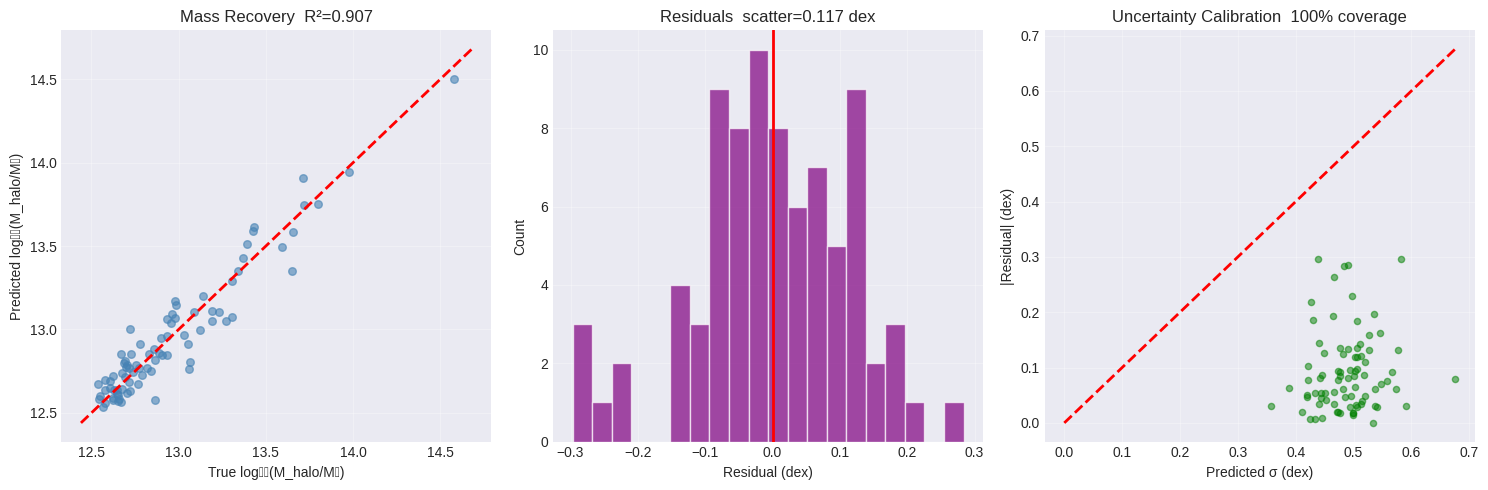

In [9]:
import os, sys, torch, numpy as np
import matplotlib.pyplot as plt
os.chdir('/kaggle/working/cosmic-net')
sys.path.insert(0, '/kaggle/working/cosmic-net')

import yaml
with open('config/config.yaml') as f:
    cfg = yaml.safe_load(f)

from data.loaders.tng_loader import TNGLoader
from graph.graph_builder import GraphBuilder
from model.model import build_model
from model.physics_loss import MetricsComputer
from torch_geometric.loader import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

loader  = TNGLoader(cfg)
halos   = loader.load()
_, _, test_h = loader.split_data(halos)
builder      = GraphBuilder(cfg)
test_graphs  = builder.build_graphs(test_h)
test_loader  = DataLoader(test_graphs, batch_size=32, shuffle=False)

save_path = ckpt_dir / 'best_model_augmented.pt'

if save_path.exists():
    checkpoint = torch.load(save_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print("Successfully loaded the Augmented Model for testing.")
else:
    print("Warning: Augmented model checkpoint not found!")

all_preds, all_targets = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        p, _  = model(batch)
        all_preds.append(p.cpu())
        all_targets.append(batch.y.squeeze(-1).cpu())

preds   = torch.cat(all_preds)
targets = torch.cat(all_targets)
metrics = MetricsComputer.compute_all(preds, targets)

print("="*40)
print("TEST SET EVALUATION — CORRECT TARGETS")
print("="*40)
print(f"  N test graphs : {len(test_graphs)}")
print(f"  MSE           : {metrics['mse']:.4f}")
print(f"  RMSE          : {metrics['rmse']:.4f} dex")
print(f"  MAE           : {metrics['mae']:.4f} dex")
print(f"  R²            : {metrics['r2']:.4f}")
print(f"  Scatter       : {metrics['scatter']:.4f} dex")
print("="*40)

# MC uncertainty
model.train()
mc_preds = []
with torch.no_grad():
    for _ in range(50):
        bp = []
        for batch in test_loader:
            batch = batch.to(device)
            p, _  = model(batch)
            bp.append(p.cpu())
        mc_preds.append(torch.cat(bp))

mc_preds  = torch.stack(mc_preds)
mc_mean   = mc_preds.mean(0)
mc_std    = mc_preds.std(0)
conf_low  = mc_mean - 1.96*mc_std
conf_high = mc_mean + 1.96*mc_std
coverage  = ((targets >= conf_low) & (targets <= conf_high)).float().mean()

print(f"\n  Mean uncertainty : {mc_std.mean():.4f} dex")
print(f"  95% CI coverage  : {coverage:.1%}  (ideal ~95%)")

# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
ax.scatter(targets.numpy(), preds.numpy(), alpha=0.6, s=30, color='steelblue')
lims = [targets.min().item()-0.1, targets.max().item()+0.1]
ax.plot(lims, lims, 'r--', lw=2)
ax.set_xlabel('True log₁₀(M_halo/M☉)')
ax.set_ylabel('Predicted log₁₀(M_halo/M☉)')
ax.set_title(f'Mass Recovery  R²={metrics["r2"]:.3f}')
ax.grid(True, alpha=0.3)

ax = axes[1]
res = (preds - targets).numpy()
ax.hist(res, bins=20, color='purple', alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', lw=2)
ax.set_xlabel('Residual (dex)')
ax.set_ylabel('Count')
ax.set_title(f'Residuals  scatter={metrics["scatter"]:.3f} dex')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.scatter(mc_std.numpy(), np.abs(res), alpha=0.5, s=20, color='green')
ax.plot([0, mc_std.max().item()], [0, mc_std.max().item()], 'r--', lw=2)
ax.set_xlabel('Predicted σ (dex)')
ax.set_ylabel('|Residual| (dex)')
ax.set_title(f'Uncertainty Calibration  {coverage:.0%} coverage')
ax.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('/kaggle/working/outputs', exist_ok=True)
plt.savefig('/kaggle/working/outputs/evaluation_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
import shutil, os
os.makedirs('/kaggle/working/outputs', exist_ok=True)

for folder in ['outputs/checkpoints', 'outputs/explanations',
               'outputs/equations', 'outputs/logs']:
    if os.path.exists(folder):
        dest = f'/kaggle/working/{folder}'
        shutil.copytree(folder, dest, dirs_exist_ok=True)
        print(f"Saved: {dest}")

print("\nDownload from Output tab:")
print("  outputs/checkpoints/best_model.pt")
print("  outputs/evaluation_v2.png")

Saved: /kaggle/working/outputs/checkpoints

Download from Output tab:
  outputs/checkpoints/best_model.pt
  outputs/evaluation_v2.png
